# Supervised Machine Learning: Classification using MediaPipe on Hand Gesture Recognition Image Dataset (HaGRID)
### Delivered by 
- Mohamed Abdelmohsen Soliman

## **Importing the required libraries**

In [1]:
import pandas as pd
import numpy as np
import mediapipe as mp
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

### Reading the data from a CSV using **Pandas** Library

In [2]:
DataPath = 'Dataset/hand_landmarks_data.csv'

In [3]:
df = pd.read_csv(DataPath)

### Viewing the dataset's first 10 rows

In [4]:
df.head(10)

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233261e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.622995e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call
5,272.454918,300.478027,-1.558500e-07,268.653831,289.496490,-0.001184,262.705101,277.195679,-0.005392,260.303741,...,238.565414,298.517212,-0.033287,232.653122,300.183655,-0.034929,228.136322,300.597046,-0.036323,call
6,286.232712,237.393692,-2.901210e-07,279.311211,221.710007,-0.003649,268.601692,209.613953,-0.009611,259.686699,...,235.806450,249.757019,-0.031268,226.319275,253.601776,-0.030820,218.499344,255.185120,-0.029436,call
7,114.953327,259.844932,-1.876879e-07,124.577408,245.503576,-0.003558,141.268433,233.379068,-0.009585,152.556953,...,157.018993,277.370584,-0.034591,163.292107,283.455908,-0.033233,168.722946,288.635302,-0.032251,call
8,178.488205,155.593403,-1.192177e-07,181.804916,150.058811,0.001126,186.087662,145.495102,-0.000282,189.005142,...,197.488068,162.990864,-0.007713,200.333069,163.943047,-0.006301,202.600998,164.469223,-0.004961,call
9,168.305664,192.957962,-2.186004e-07,175.203232,179.443233,0.001042,187.103836,168.054268,-0.003638,194.959793,...,218.690704,205.454773,-0.025292,227.284714,209.844543,-0.023056,235.106216,212.417679,-0.021292,call


#### So, we have **21 Xs**, **21 Ys**, and **21 Zs** and the Target Label, **63 features** + 1 target label = **64 total columns**

### Printing the DataFrame Info

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25675 entries, 0 to 25674
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      25675 non-null  float64
 1   y1      25675 non-null  float64
 2   z1      25675 non-null  float64
 3   x2      25675 non-null  float64
 4   y2      25675 non-null  float64
 5   z2      25675 non-null  float64
 6   x3      25675 non-null  float64
 7   y3      25675 non-null  float64
 8   z3      25675 non-null  float64
 9   x4      25675 non-null  float64
 10  y4      25675 non-null  float64
 11  z4      25675 non-null  float64
 12  x5      25675 non-null  float64
 13  y5      25675 non-null  float64
 14  z5      25675 non-null  float64
 15  x6      25675 non-null  float64
 16  y6      25675 non-null  float64
 17  z6      25675 non-null  float64
 18  x7      25675 non-null  float64
 19  y7      25675 non-null  float64
 20  z7      25675 non-null  float64
 21  x8      25675 non-null  float64
 22

In [6]:
print("Number of nulls found in the HaGRID Dataset = ", df.isnull().sum().sum())

Number of nulls found in the HaGRID Dataset =  0


#### As seen after executing the above cell, we found no Null values! Nothing to impute or drop. We are safe to go and visualize the data

## **Data Visualization**

### To assess the overall structure of the dataset, we explore the distribution and balance of values in order to understand variability, central tendency, and deviation patterns.

##### **Data Balance Check**

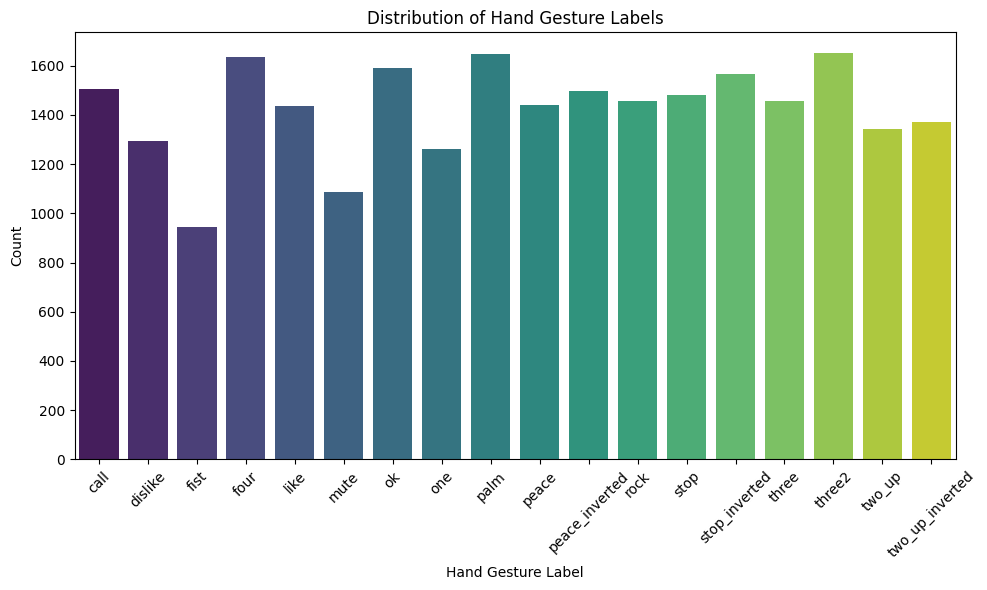

In [7]:
plt.figure(figsize=(10, 6))
sns.countplot(x="label", data=df, hue = 'label', palette='viridis')
plt.title('Distribution of Hand Gesture Labels')
plt.xlabel('Hand Gesture Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Most hand gestures labels are nearly balanced except 2 labels: Fist & mute. They are a bit under-sampled compared to the others

#### Now, lets Visualize some of the keypoints for some randomized samples and plot their landmarks

In [8]:
def get_landmarks(row):
    xs = [row[f"x{i}"] for i in range(1, 22)]
    ys = [row[f"y{i}"] for i in range(1, 22)]
    zs = [row[f"z{i}"] for i in range(1, 22)]
    return np.array(xs), np.array(ys), np.array(zs)

def finger_color(idx):
    if idx == 0: return '#AAAAAA'
    if idx <= 4: return '#FF6B6B'
    if idx <= 8: return '#FFE66D'
    if idx <= 12: return '#4ECDC4'
    if idx <= 16: return '#A29BFE'
    return '#FD79A8'

CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17),
]

In [9]:
def plot_landmarks(Conn, data, row, col, random_state=42, title="Hand Landmarks", flag = 0):

    sampled_df = data.sample(row*col, random_state=random_state)
    # print(sampled_df.head())

    fig, axes = plt.subplots(row, col, figsize=(20, 20))
    axes = axes.flatten()

    fig.suptitle(title, fontsize=16, fontweight='bold')

    for i, (idx, row) in enumerate(sampled_df.iterrows()):
        ax = axes[i]

        xs, ys, zs = get_landmarks(row)

        for (a, b) in Conn:
            ax.plot(
                [xs[a], xs[b]],
                [ys[a], ys[b]],
                c='gray',
                lw=1.5,
                alpha=0.5
            )
        colors = [finger_color(j) for j in range(21)]

        ax.scatter(xs,ys,c=colors,s=50,
            edgecolors='black',linewidths=0.5
        )

        # ax.invert_yaxis()
        ax.set_aspect('equal')
        ax.set_title(f"Sample {idx} - {row['label']}" if flag == 0 else f"Sample {idx}", fontsize=12)
        
        ax.set_aspect('equal')
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_ylim()
        
        # added padding around the landmarks to prevent them from being too close to the edges
        padx = 0.3
        pady = 0.2
        x_min, x_max = xs.min(), xs.max()
        y_min, y_max = ys.min(), ys.max()
        x_range = x_max - x_min
        y_range = y_max - y_min
        ax.set_xlim(x_min - padx*x_range, x_max + padx*x_range)
        ax.set_ylim(y_max + pady*y_range, y_min - pady*y_range)

    plt.tight_layout()
    plt.show()

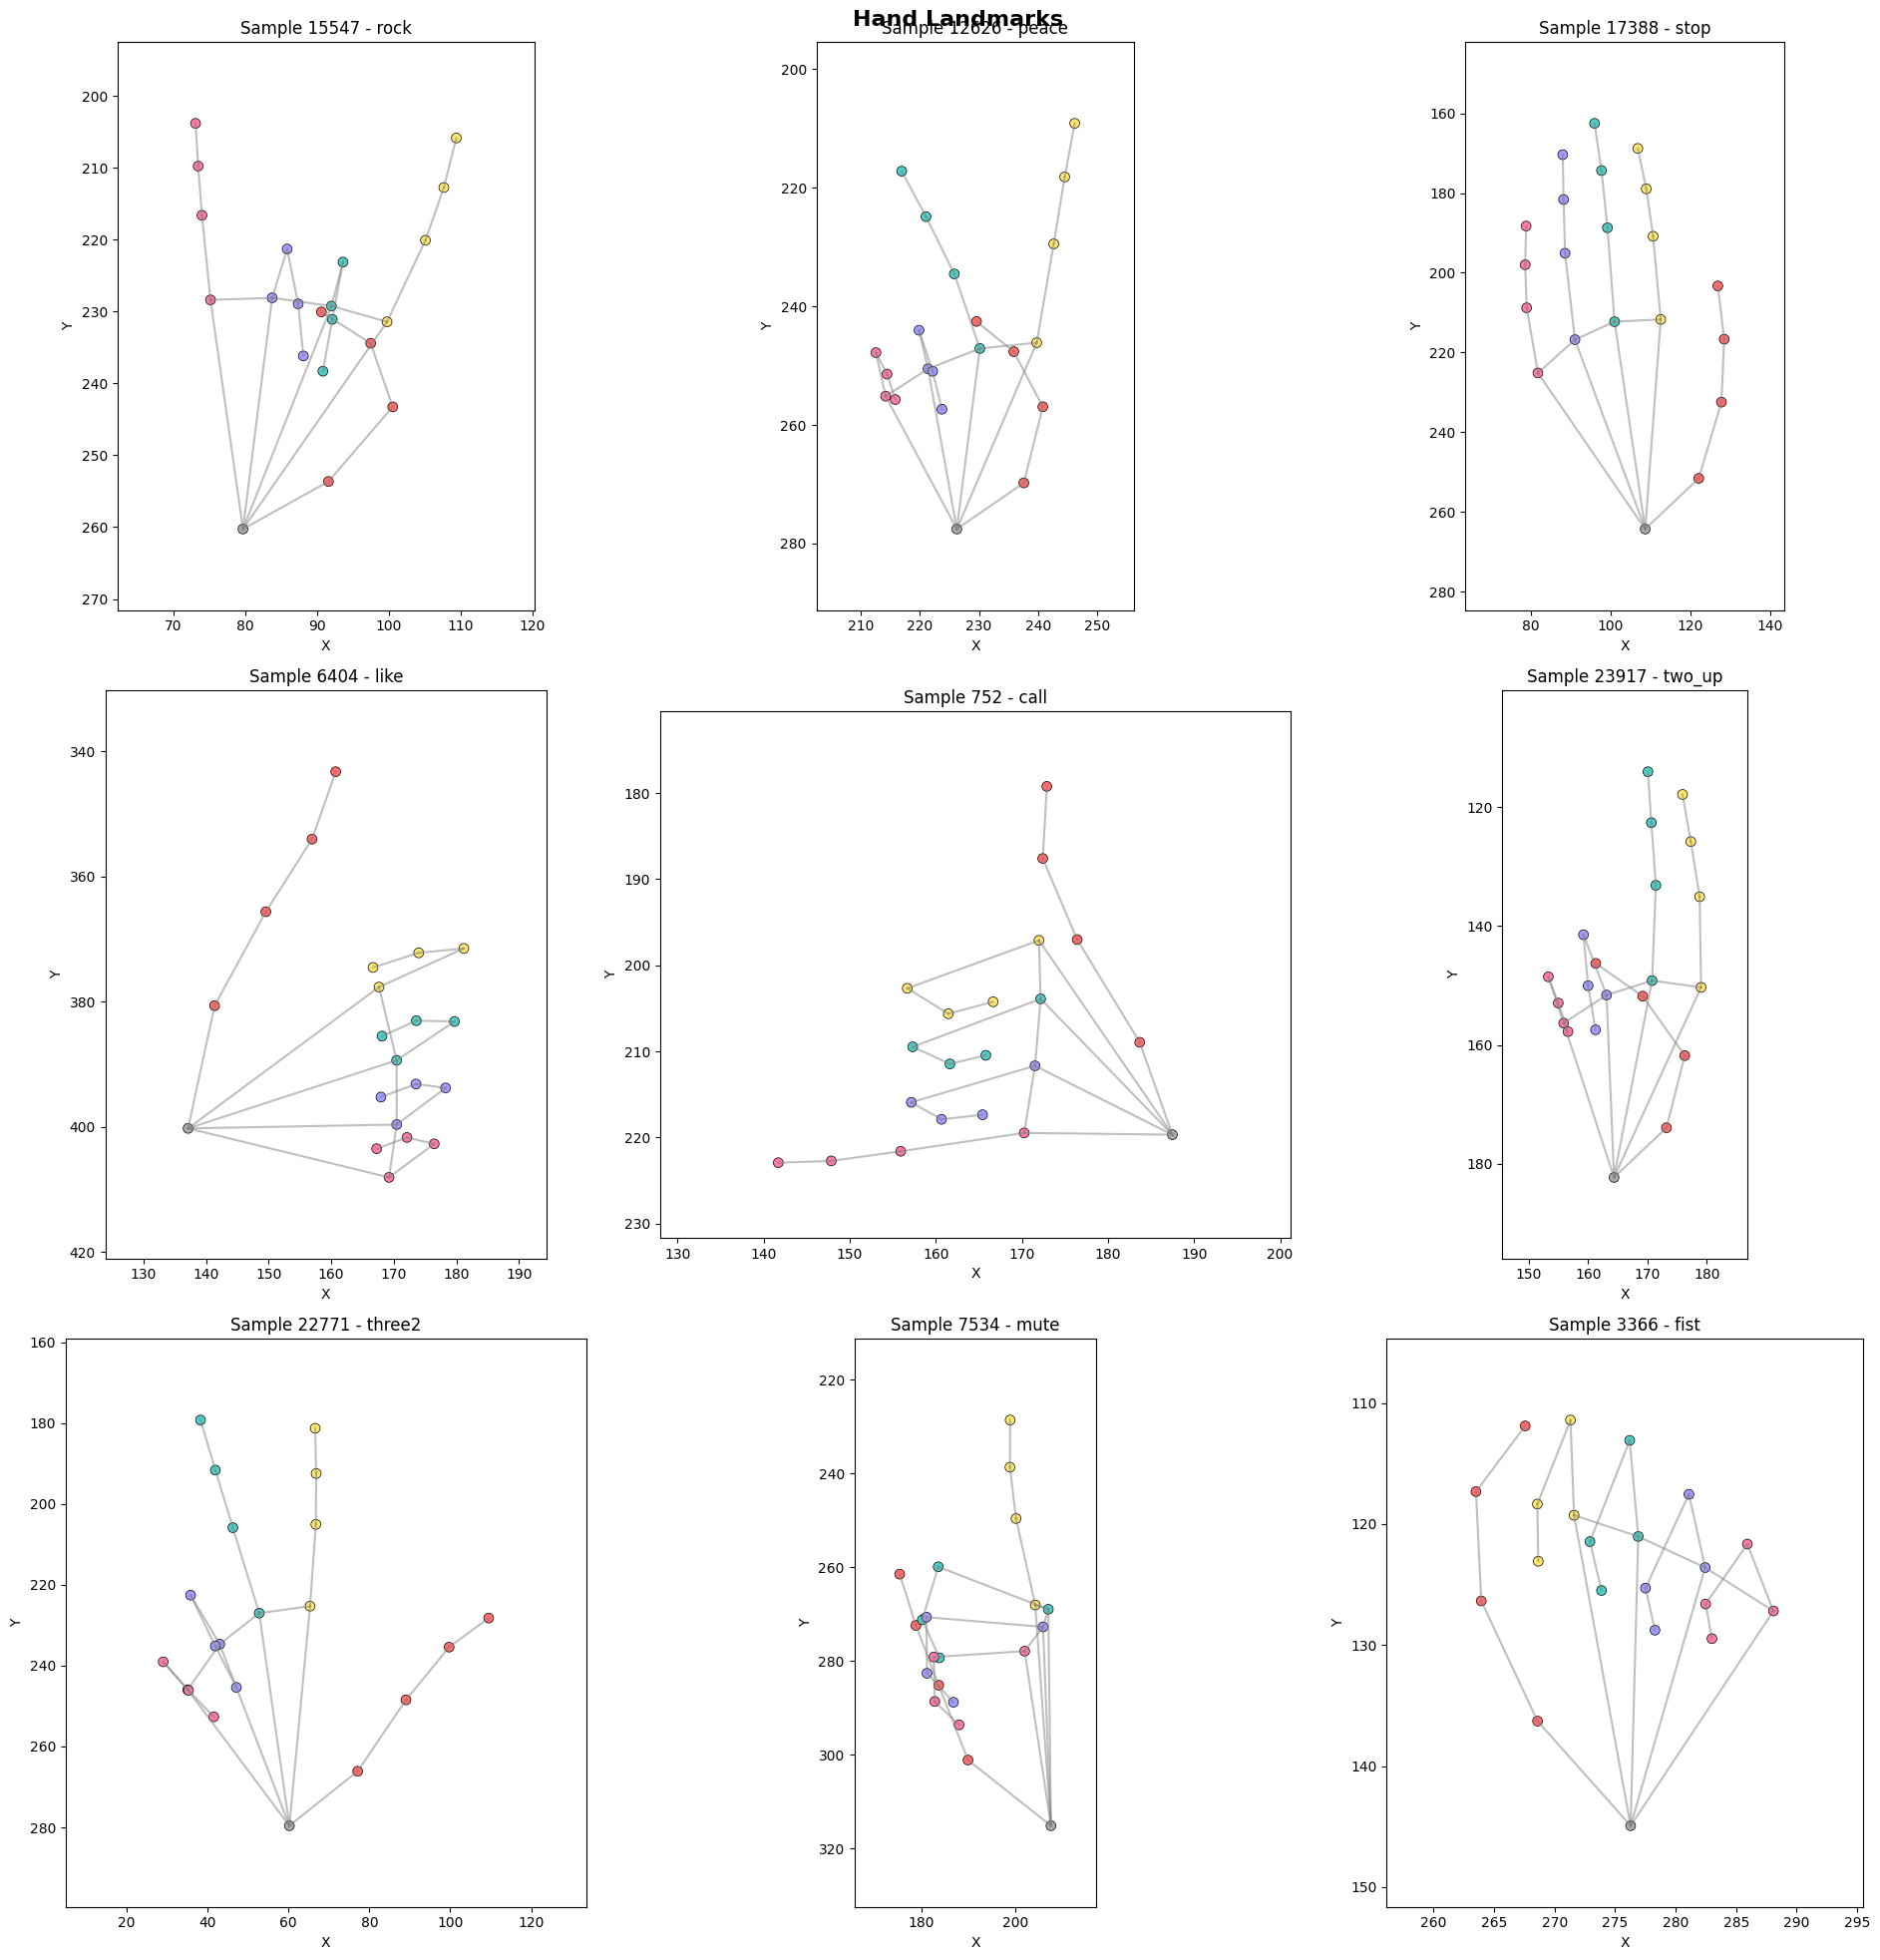

In [10]:
plot_landmarks(CONNECTIONS, df, 3, 3)

#### Those are samples of the landmarks and keypoints that are on the hand shape before normalization

## **Preprocessing & Normalization**

#### **Detecting Outliers**

In [11]:
X = df.iloc[:, :-1]
Y = df['label']
Y

0                   call
1                   call
2                   call
3                   call
4                   call
              ...       
25670    two_up_inverted
25671    two_up_inverted
25672    two_up_inverted
25673    two_up_inverted
25674    two_up_inverted
Name: label, Length: 25675, dtype: object

### I will group each label and detect the outliers within

In [12]:
def OutlierDetect_IQR(X, Y):
    outlier_indices = []
    LabelsOuts = {}
    for label in Y.unique():        
        label_mask = Y == label
        X_label = X[label_mask]
        
        Q1 = X_label.quantile(0.25)
        Q3 = X_label.quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outlier_mask = ((X_label < lower_bound) | 
                        (X_label > upper_bound)).any(axis=1)
        
        original_indices = X_label.index[outlier_mask].tolist()
        outlier_indices.extend(original_indices)
        LabelsOuts[label] = original_indices
    return outlier_indices, LabelsOuts

#### Seeing the count of the outliers detected in the dataset

In [13]:
OutS, LabelsOuts = OutlierDetect_IQR(X, Y)

print(f"\n=== SUMMARY ===")
print(f"Total samples: {len(df)}")
print(f"Total outliers: {len(OutS)}")

for label in Y.unique():
    print(f"Label '{label}': {len(LabelsOuts[label])} outliers")
    
print(f"Clean samples: {len(df) - len(OutS)}")


=== SUMMARY ===
Total samples: 25675
Total outliers: 3783
Label 'call': 314 outliers
Label 'dislike': 270 outliers
Label 'fist': 162 outliers
Label 'four': 143 outliers
Label 'like': 296 outliers
Label 'mute': 314 outliers
Label 'ok': 181 outliers
Label 'one': 153 outliers
Label 'palm': 177 outliers
Label 'peace': 202 outliers
Label 'peace_inverted': 285 outliers
Label 'rock': 168 outliers
Label 'stop': 189 outliers
Label 'stop_inverted': 197 outliers
Label 'three': 141 outliers
Label 'three2': 203 outliers
Label 'two_up': 147 outliers
Label 'two_up_inverted': 241 outliers
Clean samples: 21892


Outliers were detected using the IQR method. However, they were not removed because the number of detected samples was small and may represent natural variations in hand pose rather than erroneous data. Additionally, the models used in this project are generally robust to moderate outliers specially tree based models used below.

Additionally, the data will be going through the landmark normalization process using the below function "normalize_landmarks". Therefore, no data were dropped since influence of extreme values is mitigated during preprocessing.

## **Data Preprocessing**

#### Steps I have followed below in order:

1. **Encoding the Y Label**  
   Convert the target variable into numerical form.

2. **Splitting X and Y using `train_test_split()`**  
   Separate features (X) and labels (Y) into training and testing sets.

3. **Normalizing `X_train` and `X_test` separately**  
   Apply normalization using normalize_landmarks() function I have implemented on `X_train` and `X_test`


### **Normalization Function**, will be used after splitting on **X_Train** and **X_Test** Separately to avoid **Data Leakage**

##### How was the data normalized?
- All hand landmarks were shifted relative to the wrist (landmark 0) to align the spatial origins across the dataset.

- The geometric features were normalized by dividing all coordinates by the Euclidean distance between the wrist and the middle finger, neutralizing variations in physical hand size or camera distance.

- The identical normalization function used during training is applied to the extracted landmarks during real-time webcam inference prior to model prediction.

In [14]:
def normalize_landmarks(X):
    X_normalized = X.copy() # first i copied the original dataframe to avoid modifying it directly
    n_samples = len(X)
    
    # bring all the landmarks into a 3D array for easier processing
    xs = X[[f'x{i}' for i in range(1, 22)]].values
    ys = X[[f'y{i}' for i in range(1, 22)]].values
    zs = X[[f'z{i}' for i in range(1, 22)]].values
    
    landmarks = np.stack((xs, ys, zs), axis=2)
    
    for i in range(n_samples):
        # and for each sample, normalize the landmarks by translating them to the origin and 
        # scaling them by the distance between the wrist and the middle finger tip (landmark 12)
        hand = landmarks[i]
        hand = hand - hand[0]
        
        hand_size = np.linalg.norm(hand[12])
        if hand_size > 0:
            hand = hand / hand_size
            
        landmarks[i] = hand
        
    X_normalized[[f'x{i}' for i in range(1, 22)]] = landmarks[:, :, 0]
    X_normalized[[f'y{i}' for i in range(1, 22)]] = landmarks[:, :, 1]
    X_normalized[[f'z{i}' for i in range(1, 22)]] = landmarks[:, :, 2]
    
    return X_normalized

### Transforming the Y into Encoded Numbers using **LabelEncoder**
##### Since Class labels are by default string objects, LabelEncoder convert them into number 0-17

In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Y = le.fit_transform(Y)

##### Checking the Label Mapping

In [16]:
print("Label classes:", le.classes_)
for i in range(len(le.classes_)):
    print(f"Class '{le.classes_[i]}' is encoded as {i}")

Label classes: ['call' 'dislike' 'fist' 'four' 'like' 'mute' 'ok' 'one' 'palm' 'peace'
 'peace_inverted' 'rock' 'stop' 'stop_inverted' 'three' 'three2' 'two_up'
 'two_up_inverted']
Class 'call' is encoded as 0
Class 'dislike' is encoded as 1
Class 'fist' is encoded as 2
Class 'four' is encoded as 3
Class 'like' is encoded as 4
Class 'mute' is encoded as 5
Class 'ok' is encoded as 6
Class 'one' is encoded as 7
Class 'palm' is encoded as 8
Class 'peace' is encoded as 9
Class 'peace_inverted' is encoded as 10
Class 'rock' is encoded as 11
Class 'stop' is encoded as 12
Class 'stop_inverted' is encoded as 13
Class 'three' is encoded as 14
Class 'three2' is encoded as 15
Class 'two_up' is encoded as 16
Class 'two_up_inverted' is encoded as 17


### Splitting the Dataset into Train and Test

##### We will split the dataset into **80%** train and **20%** test

A fixed random train-test split was used in the reported experiments with **random_state=42** to ensure reproducibility.

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

##### Let us check the conversion of Y label into numerical features

In [18]:
Y

array([ 0,  0,  0, ..., 17, 17, 17])

###### Perfect

## **Scaling using the Normalization Function above**

##### **As mentioned above, we will normalize the X_train and X_test separately to avoid any data leakage**

In [19]:
X_train = normalize_landmarks(X_train)
X_test = normalize_landmarks(X_test)

##### Viewing the first 5 rows to take a look on the normalized data around the wrist

In [20]:
X_train.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,z18,x19,y19,z19,x20,y20,z20,x21,y21,z21
7330,0.0,0.0,0.0,0.467282,-0.142106,-0.000184,0.747463,-0.353930,-0.000517,0.987460,...,-0.001128,0.818343,-0.774184,-0.001461,0.734846,-0.565419,-0.001300,0.552655,-0.510212,-0.001106
19295,0.0,0.0,0.0,0.184624,-0.137144,-0.000055,0.254687,-0.326158,-0.000091,0.179122,...,-0.000236,-0.263026,-0.550976,-0.000303,-0.281813,-0.661543,-0.000342,-0.295688,-0.755152,-0.000362
13987,0.0,0.0,0.0,-0.123518,-0.198716,-0.000020,-0.110808,-0.369209,-0.000111,0.014976,...,-0.000437,0.208371,-0.406885,-0.000459,0.165453,-0.365293,-0.000366,0.146630,-0.307954,-0.000275
826,0.0,0.0,0.0,-0.110586,-0.360561,-0.000021,-0.348704,-0.748729,-0.000102,-0.484989,...,-0.000296,-1.385530,0.178148,-0.000415,-1.578634,0.365051,-0.000489,-1.755221,0.491985,-0.000544
3008,0.0,0.0,0.0,-0.347705,-0.316322,-0.000349,-0.597438,-0.798163,-0.000444,-0.750595,...,-0.000358,0.273392,-0.933459,-0.000654,0.171562,-0.676241,-0.000453,0.134743,-0.617248,-0.000222


In [21]:
print("Before normalization")
print(X.iloc[:5, :3])

print("\nAfter normalization")
print(X_train.iloc[:5, :3])

Before normalization
           x1          y1            z1
0  262.669968  257.304901 -3.649205e-07
1   83.351778  346.059113 -2.345265e-07
2  187.756977  260.235492 -2.417307e-07
3  114.976696  331.594238 -1.233261e-07
4  188.795288  141.727867 -1.622995e-07

After normalization
        x1   y1   z1
7330   0.0  0.0  0.0
19295  0.0  0.0  0.0
13987  0.0  0.0  0.0
826    0.0  0.0  0.0
3008   0.0  0.0  0.0


### **Below are the Landmarks and Keypoints on the hand shape after normalization around the wrist!**

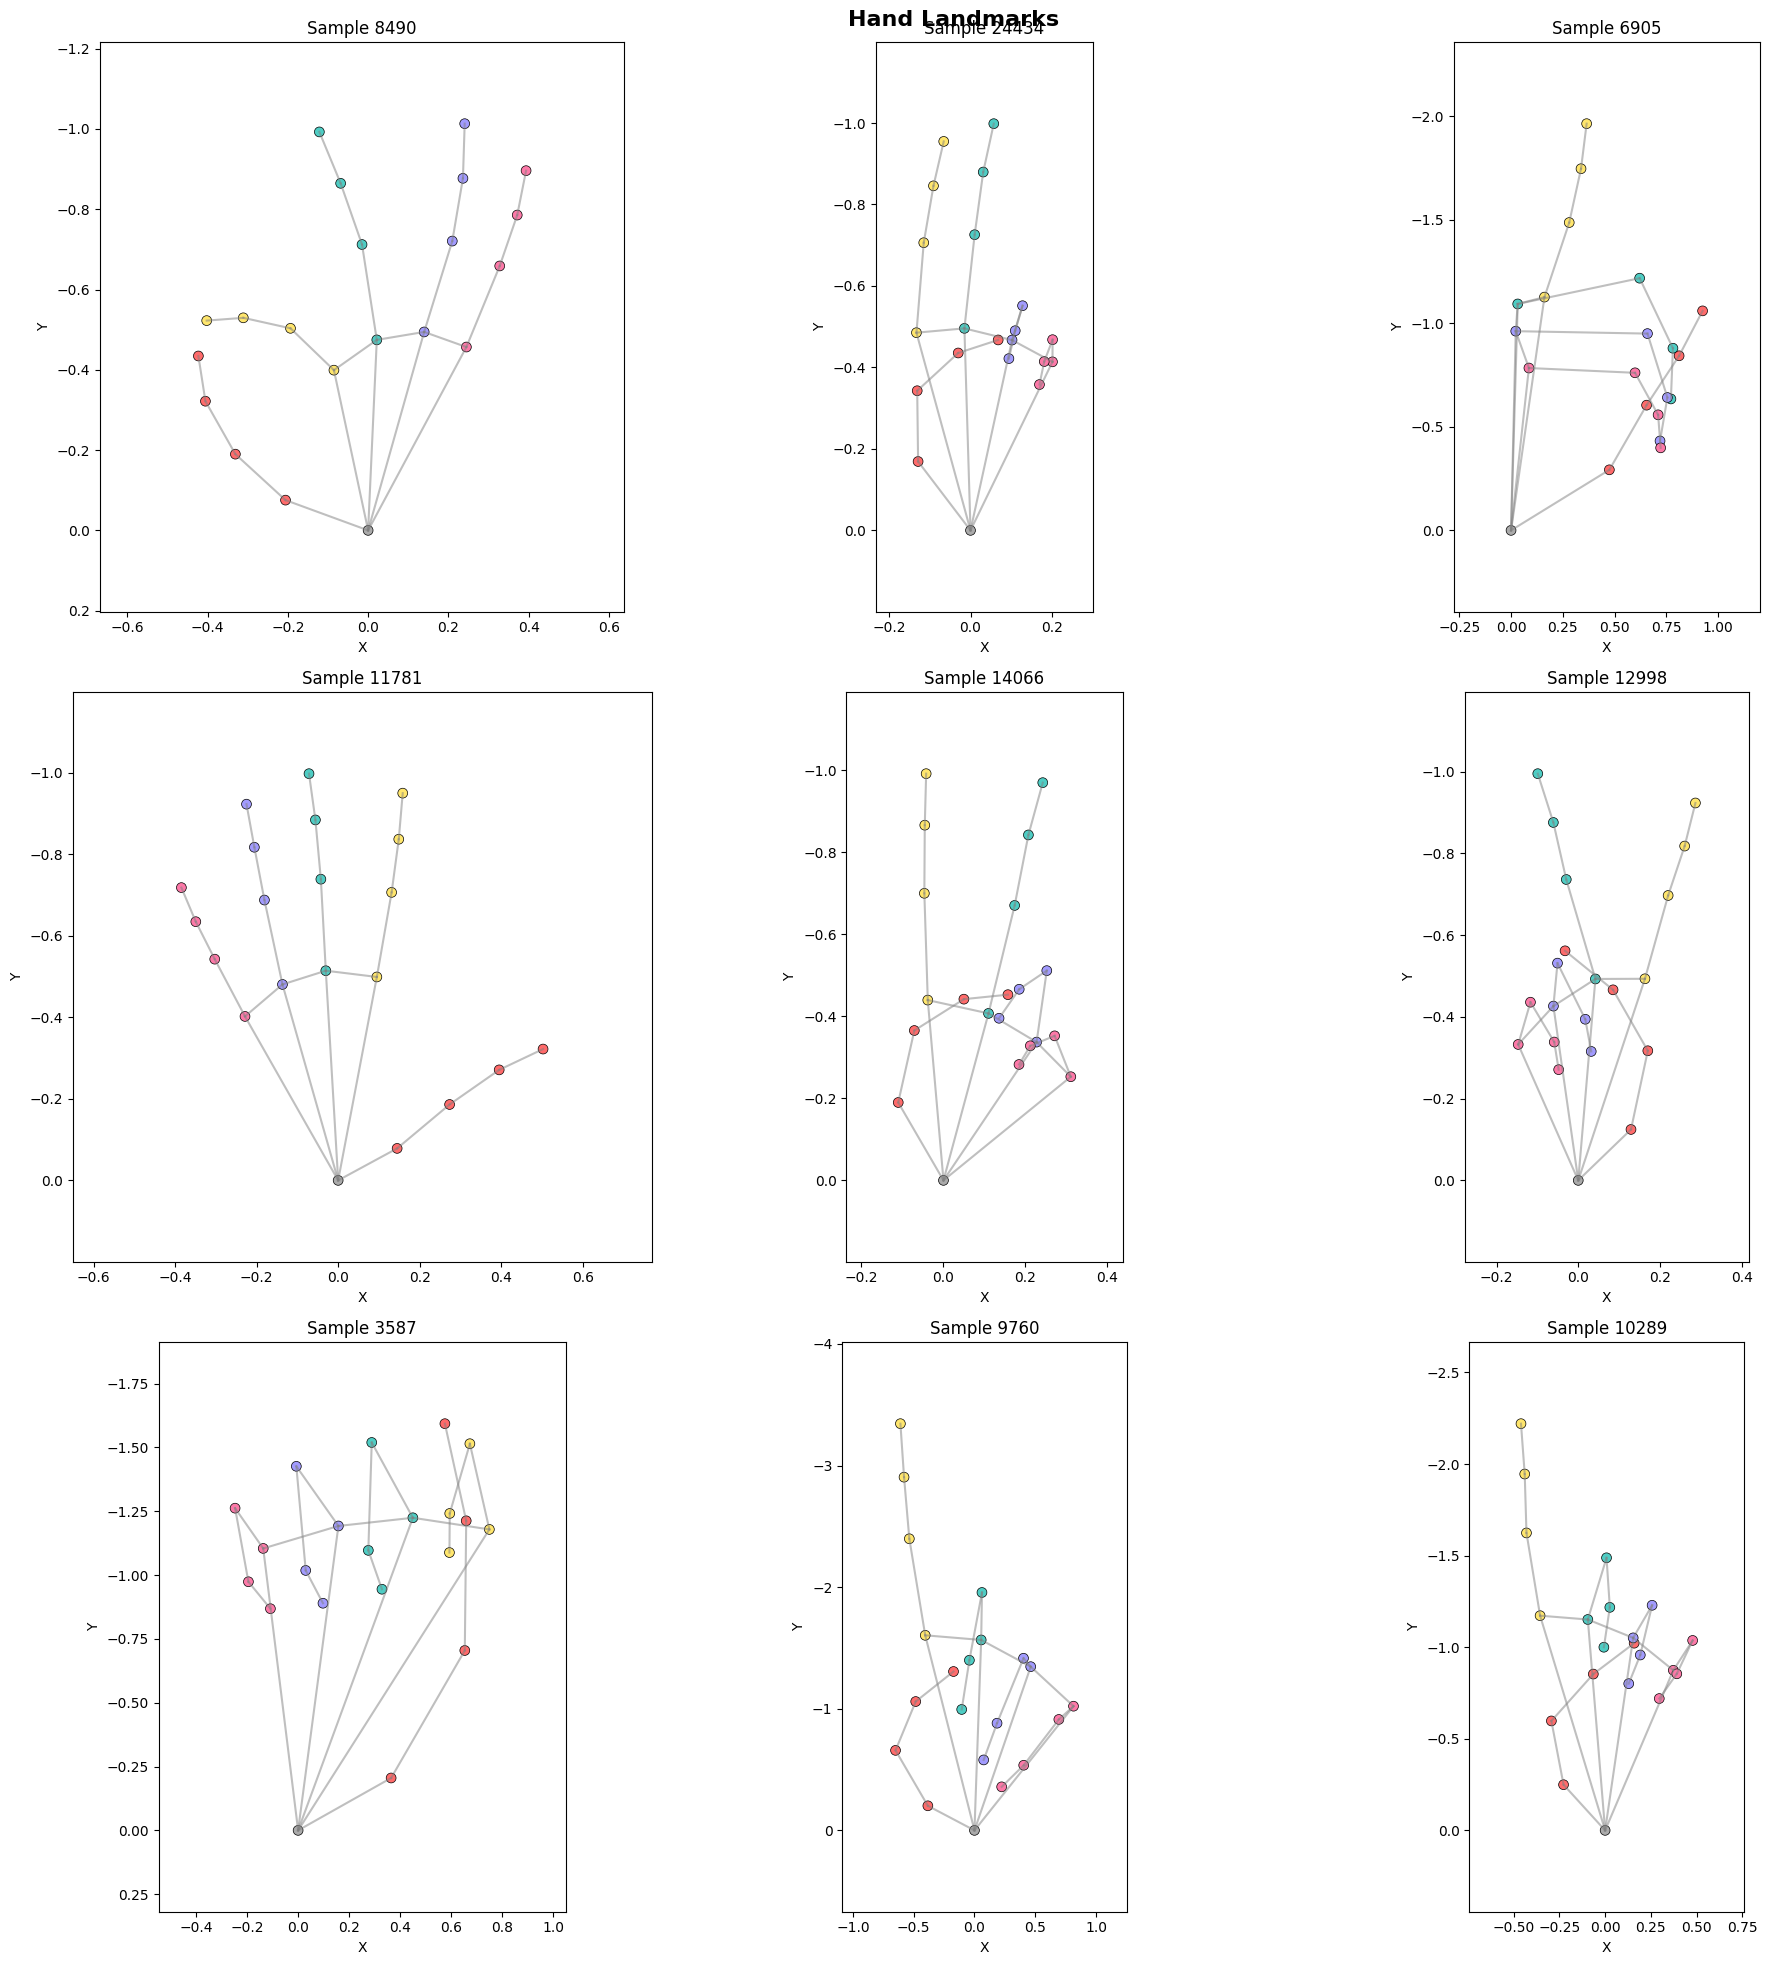

In [22]:
plot_landmarks(CONNECTIONS, X_train , 3, 3, flag=1)

## **Model & Training Phase**

In this phase, multiple machine learning models were trained and evaluated, followed by combining the best-performing models using an ensemble technique.

### **Models Used**

1. **Random Forest** — Test Accuracy: **97.59%**
2. **XGBoost** — Test Accuracy: **98.05%**
3. **K-Nearest Neighbors (KNN)** — Test Accuracy: **97.37%**
4. **Support Vector Machine (SVM)** — Test Accuracy: **98.38%**

---

### **Ensemble Model**

5. **Voting Classifier**

A Voting Classifier was created by combining the following models:

- Random Forest  
- XGBoost  
- KNN  
- SVM  

The final prediction is determined using **soft voting**, where the predicted class probabilities from all models are averaged and the class with the highest combined probability is selected.

This ensemble approach improved the overall performance and achieved the **highest test accuracy of 98.42%**, outperforming all individual models.

## **Random Forest Model**

In [ ]:
RF_Model = RandomForestClassifier(n_estimators=200, max_depth=1000, random_state=42, n_jobs=-1)
RF_Model.fit(X_train, Y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,1000
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### **Testing & Training Accuracies for Random Forest**

In [24]:
RfPreds = RF_Model.predict(X_test)
RfPreds_train = RF_Model.predict(X_train)
TrainAccuracy = accuracy_score(Y_train, RfPreds_train)
print(f"Random Forest Training Accuracy: {TrainAccuracy:.4f} ({TrainAccuracy*100:.2f}%)")
TestAccuracy = accuracy_score(Y_test, RfPreds)
print(f"Random Forest Test Accuracy: {TestAccuracy:.4f} ({TestAccuracy*100:.2f}%)")


Random Forest Training Accuracy: 1.0000 (100.00%)
Random Forest Test Accuracy: 0.9759 (97.59%)


#### **Precision, Recall, and F1 Metrics for Random Forest**

In [25]:
precision = precision_score(Y_test, RfPreds, average='macro', zero_division=0)
recall = recall_score(Y_test, RfPreds, average='macro', zero_division=0)
f1 = f1_score(Y_test, RfPreds, average='macro', zero_division=0)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Precision: 0.9755
Recall: 0.9755
F1-Score: 0.9754


### **RF Confusion Matrix**

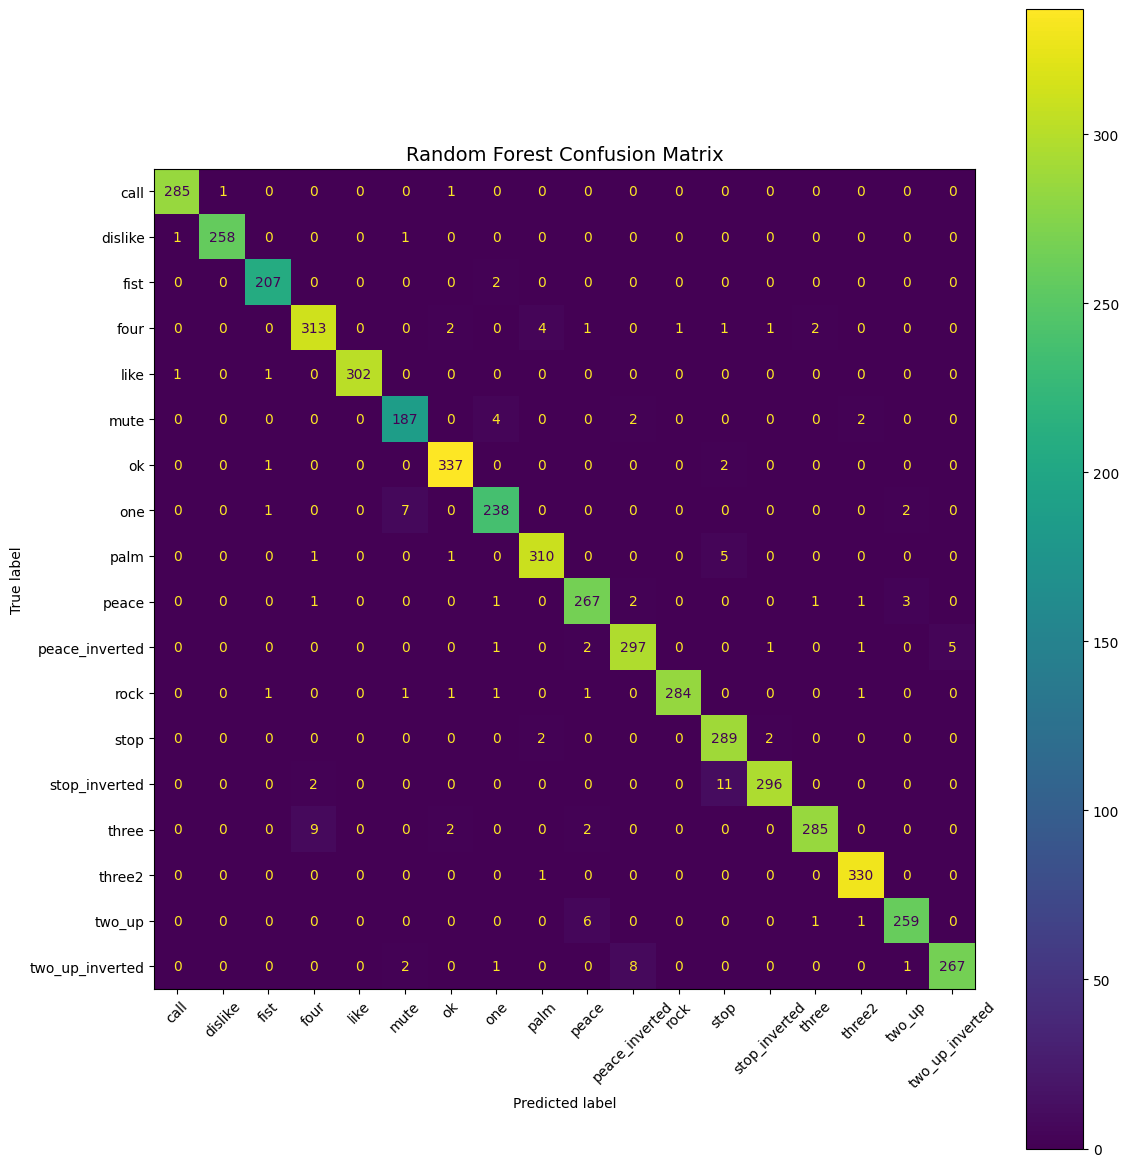

In [26]:
CmPath = 'assets/RandomForest/rf_confusion_matrix.png'
fig, ax = plt.subplots(figsize=(12, 12))
cm = confusion_matrix(Y_test, RfPreds)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap='viridis', xticks_rotation=45, ax=ax)
ax.set_title("Random Forest Confusion Matrix", fontsize=14)
plt.savefig(CmPath)
plt.tight_layout()
plt.show()

In [27]:
def plot_perclass_f1(model_name, preds, Y_test, label_names, save_path=None):
    report = classification_report(Y_test, preds, target_names=label_names, output_dict=True)
    f1s = [report[label]["f1-score"] for label in label_names]

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(label_names, f1s, color='steelblue')
    ax.set_xlabel("Gesture Class")
    ax.set_ylabel("F1-Score")
    ax.set_title(f"Per-Class F1-Score — {model_name}")
    ax.set_ylim(0, 1.1)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    if save_path is None:
        save_path = f"assets/{model_name}/{model_name}_perclass_f1.png"
    plt.savefig(save_path)
    plt.show()

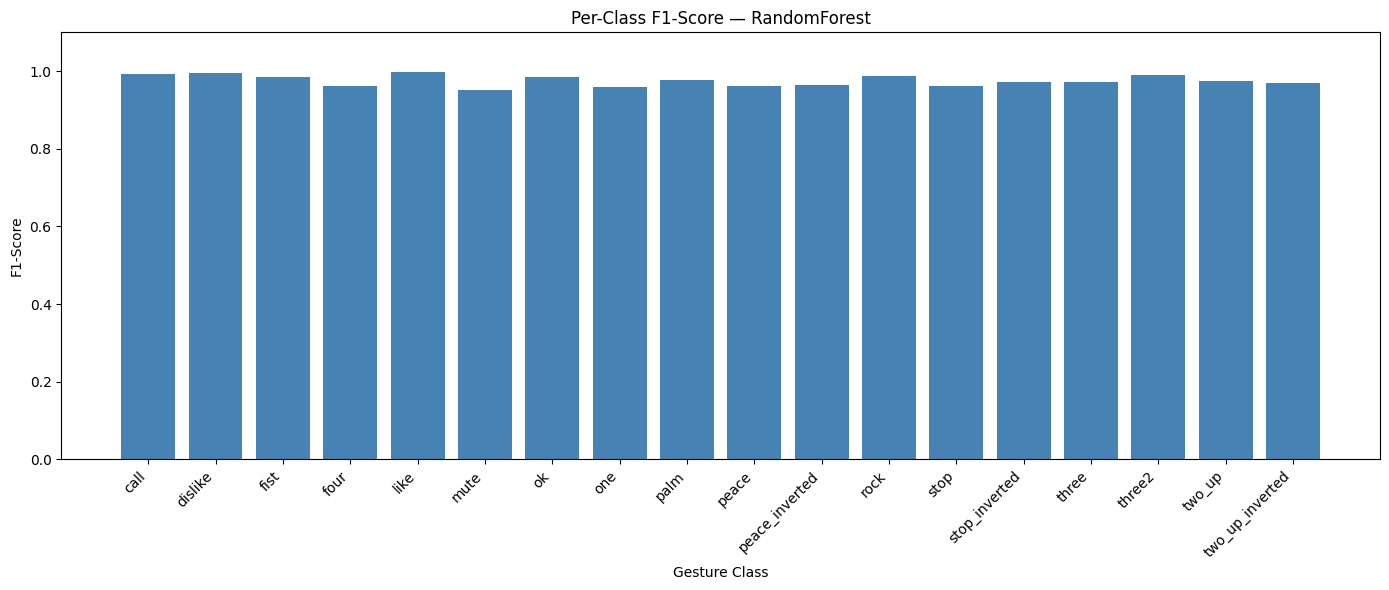

In [28]:
model_name = 'RandomForest'
plot_perclass_f1(model_name, RfPreds, Y_test, le.classes_)

## **K Nearest Neighbours Model**

KNN Training Accuracy: 1.0000 (100.00%)
KNN Test Accuracy: 0.9737 (97.37%)
Precision: 0.9735
Recall: 0.9735
F1-Score: 0.9735


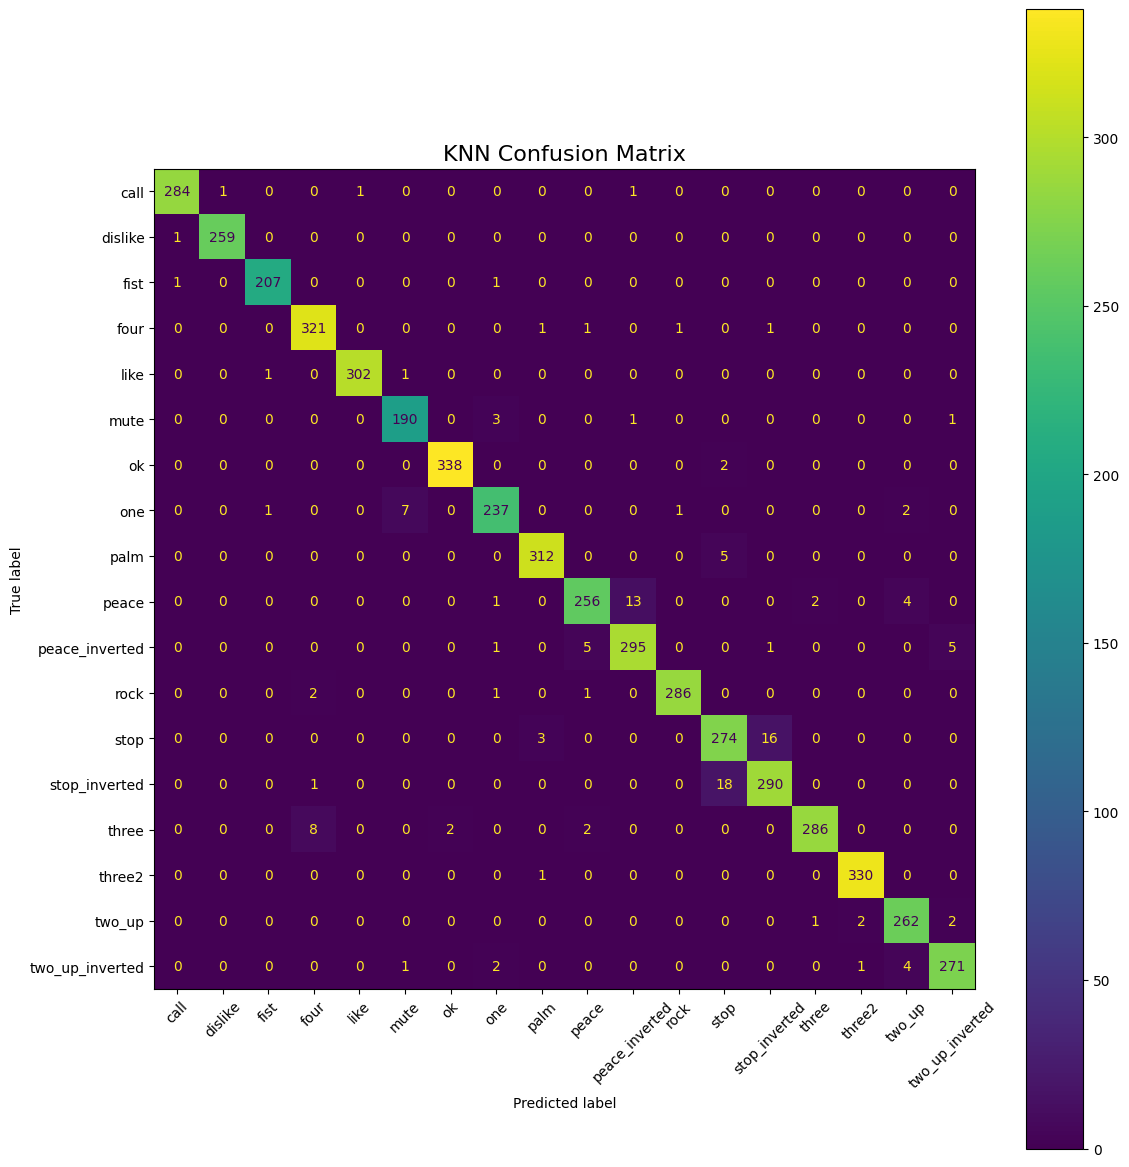

In [29]:

KNN_Model = KNeighborsClassifier(n_neighbors=4, weights='distance')
KNN_Model.fit(X_train, Y_train)
KNNPreds = KNN_Model.predict(X_test)
KNNPreds_train = KNN_Model.predict(X_train)

# calculate and print test and train accuracy, precision, recall, and F1-score for KNN
TrainAccuracy = accuracy_score(Y_train, KNNPreds_train)
print(f"KNN Training Accuracy: {TrainAccuracy:.4f} ({TrainAccuracy*100:.2f}%)")
TestAccuracy = accuracy_score(Y_test, KNNPreds)
print(f"KNN Test Accuracy: {TestAccuracy:.4f} ({TestAccuracy*100:.2f}%)")

precision = precision_score(Y_test, KNNPreds, average='macro', zero_division=0)
recall = recall_score(Y_test, KNNPreds, average='macro', zero_division=0)
f1 = f1_score(Y_test, KNNPreds, average='macro', zero_division=0)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# saving and plotting the confusion matrix for KNN
CmPath = "assets/KNN/KNN_ConfMatrix.png"
cm = confusion_matrix(Y_test, KNNPreds)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap='viridis', xticks_rotation=45, ax=ax)
ax.set_title("KNN Confusion Matrix", fontsize=16)
plt.savefig(CmPath)
plt.tight_layout()
plt.show()


##### For KNN, there are occasionally a few misclassified labels, particularly among related gestures such as Peace, Peace_Inverted, Stop, and Stop_Inverted. This is because KNN is distance-based, and these gestures have very similar feature representations.

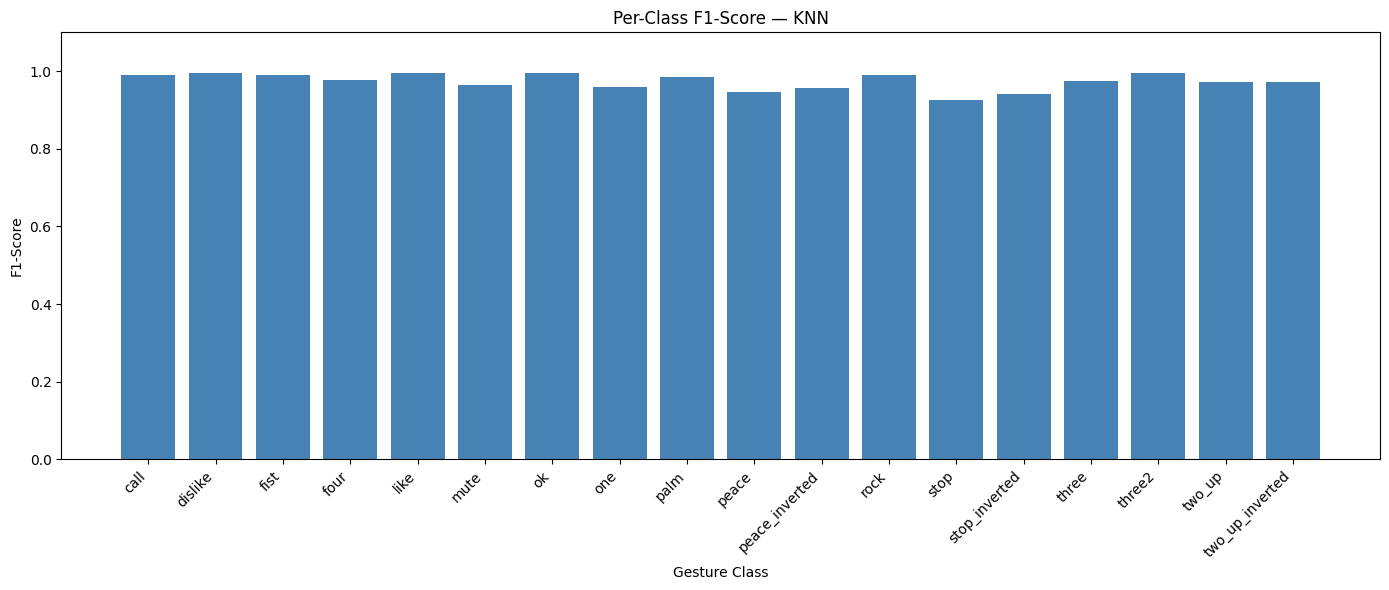

In [30]:
model_name = "KNN"
plot_perclass_f1(model_name, KNNPreds, Y_test, le.classes_)

## **XGBoost**

In [31]:
import xgboost as xgb
model_name = "XGBoost"
XGB_Model = xgb.XGBClassifier(n_estimators=450, max_depth=550, learning_rate=0.092, random_state=42, n_jobs=-1)
XGB_Model.fit(X_train, Y_train)
XGBPreds = XGB_Model.predict(X_test)
XGBPreds_train = XGB_Model.predict(X_train)

#  the training accuracy for XGBoost
TrainAccuracy = accuracy_score(Y_train, XGBPreds_train)
print(f"XGBoost Training Accuracy: {TrainAccuracy:.4f} ({TrainAccuracy*100:.2f}%)")
# the test accuracy for XGBoost
TestAccuracy = accuracy_score(Y_test, XGBPreds)
print(f"XGBoost Test Accuracy: {TestAccuracy:.4f} ({TestAccuracy*100:.2f}%)")
# precision, recall, and F1-score
precision = precision_score(Y_test, XGBPreds, average='macro', zero_division=0)
recall = recall_score(Y_test, XGBPreds, average='macro', zero_division=0)
f1 = f1_score(Y_test, XGBPreds, average='macro', zero_division=0)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

XGBoost Training Accuracy: 1.0000 (100.00%)
XGBoost Test Accuracy: 0.9805 (98.05%)
Precision: 0.9801
Recall: 0.9803
F1-Score: 0.9802


**XGBoost Confusion Matrix**

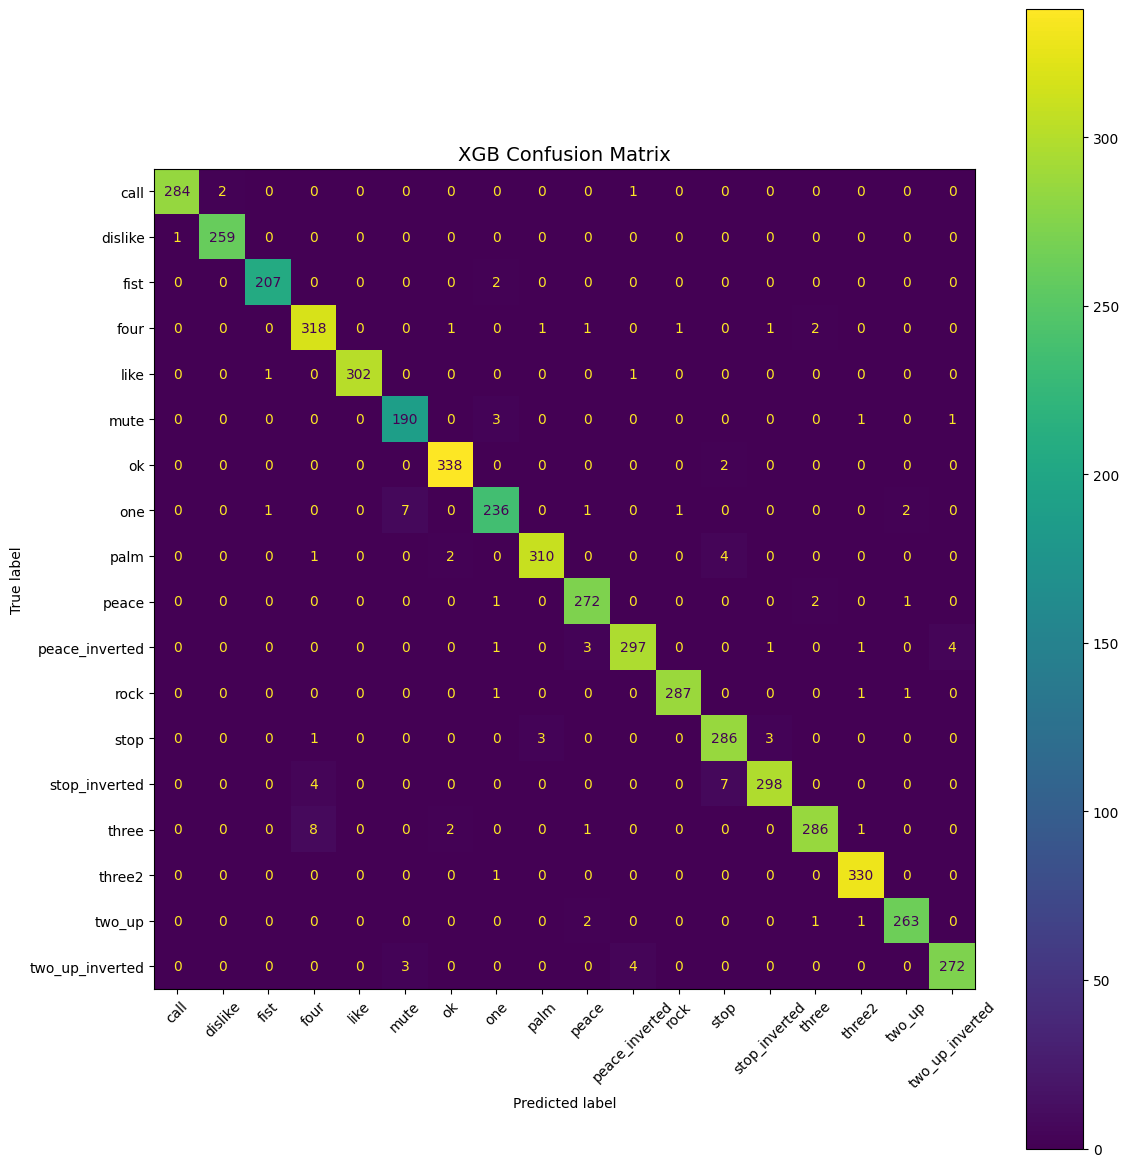

In [32]:
CmPath = "assets/XGBoost/XGBoost_CF.png"
fig, ax = plt.subplots(figsize=(12, 12))
cm = confusion_matrix(Y_test, XGBPreds)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap='viridis', xticks_rotation=45, ax=ax)
plt.savefig(CmPath)
ax.set_title("XGB Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()

##### As we can see that the confusion matrix is predicting very well, very few misclassified labels. Slightly better performing than KNNs

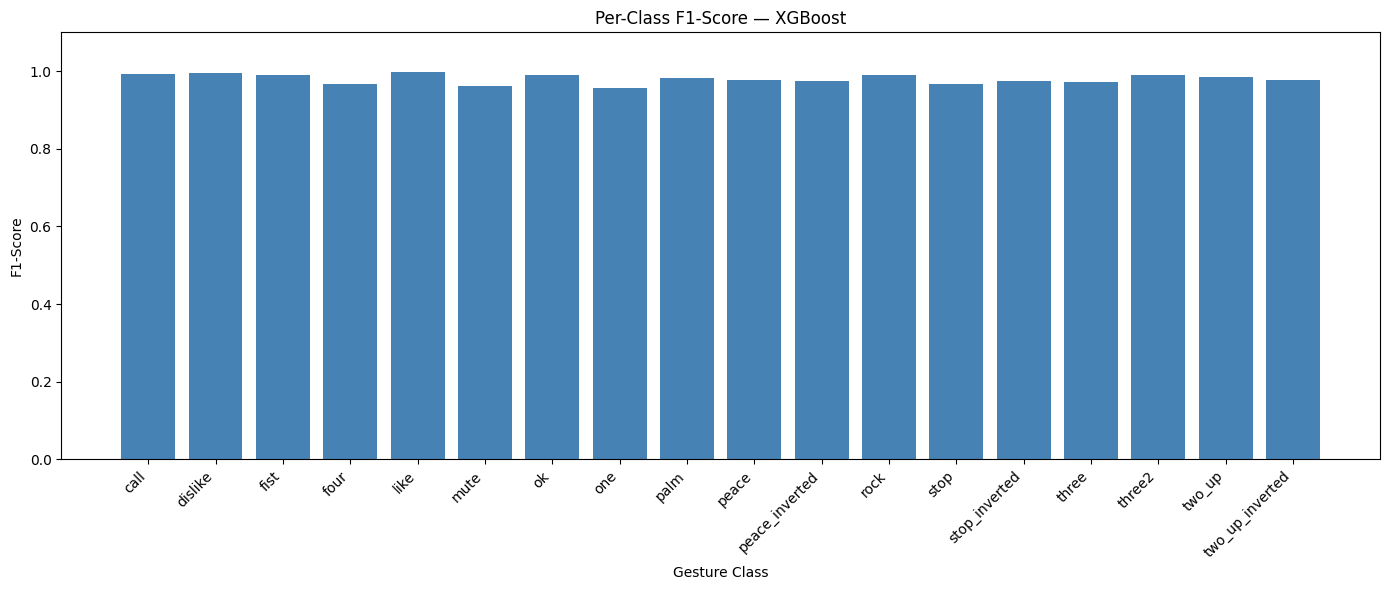

In [33]:
plot_perclass_f1(model_name, XGBPreds, Y_test, le.classes_)

## **SVM**

 - I set probability = True in SVM to then use it in the soft voting ensemble approach below

In [34]:
SVM_Model = SVC(kernel='rbf', C=55, gamma='scale', random_state=42, probability=True)
SVM_Model.fit(X_train, Y_train)
SVCPreds = SVM_Model.predict(X_test)
SVCPreds_train = SVM_Model.predict(X_train)

#  the training accuracy for SVM
TrainAccuracy = accuracy_score(Y_train, SVCPreds_train)
print(f"SVM Training Accuracy: {TrainAccuracy:.4f} ({TrainAccuracy*100:.2f}%)")

TestAccuracy = accuracy_score(Y_test, SVCPreds)
print(f"SVM Test Accuracy: {TestAccuracy:.4f} ({TestAccuracy*100:.2f}%)")

precision = precision_score(Y_test, SVCPreds, average='macro', zero_division=0)
recall = recall_score(Y_test, SVCPreds, average='macro', zero_division=0)
f1 = f1_score(Y_test, SVCPreds, average='macro', zero_division=0)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

SVM Training Accuracy: 0.9883 (98.83%)
SVM Test Accuracy: 0.9838 (98.38%)
Precision: 0.9832
Recall: 0.9835
F1-Score: 0.9833


### **SVM CM**

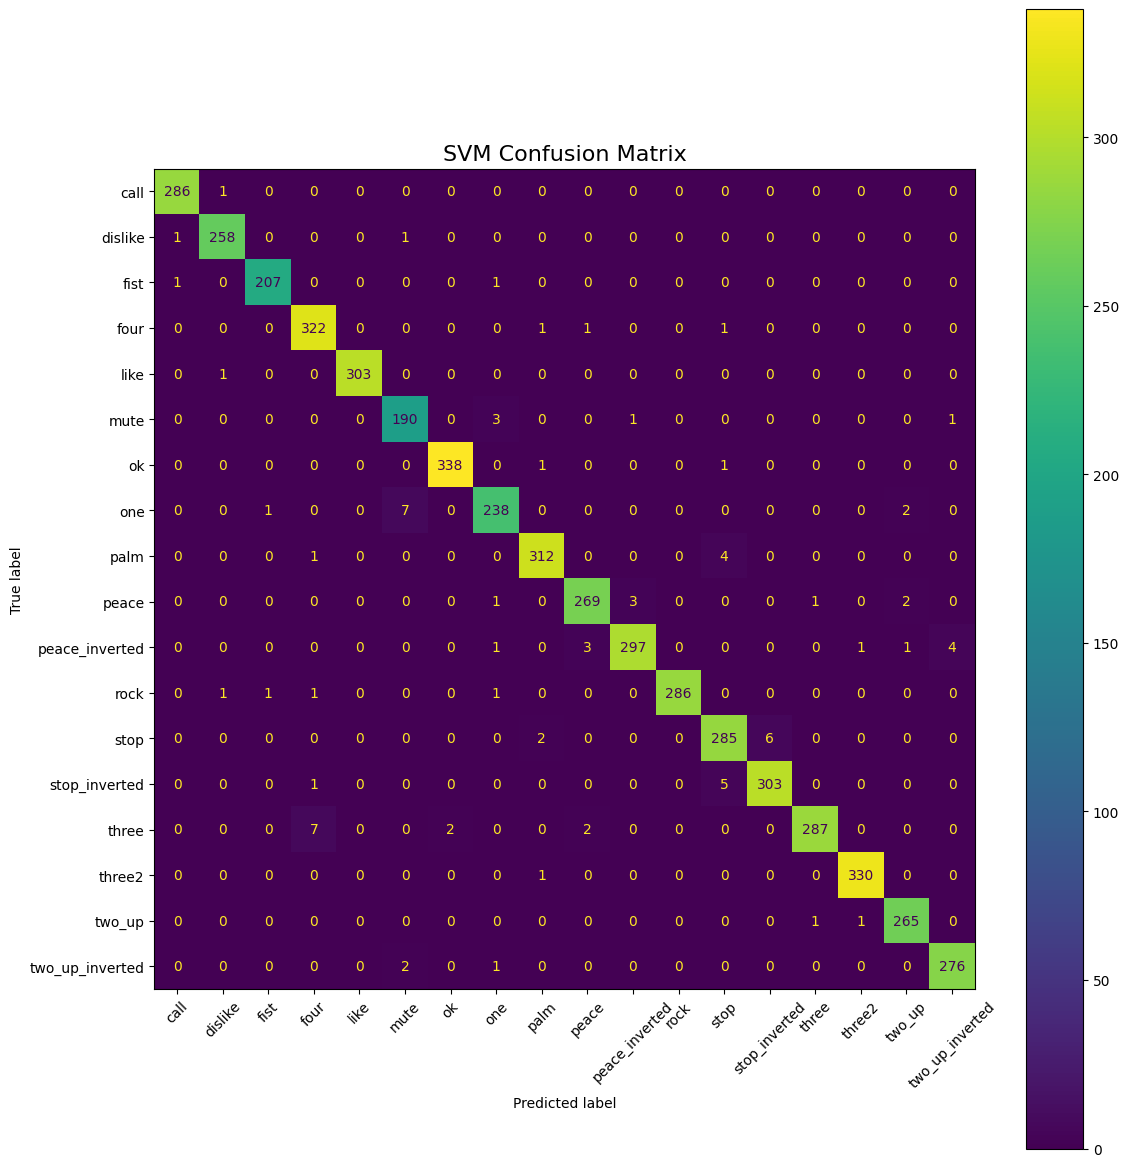

In [35]:
CmPath = "assets/SVM/SVM_CM.png"
cm = confusion_matrix(Y_test, SVCPreds)
model_name = "SVM"
fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap='viridis', xticks_rotation=45, ax=ax)
ax.set_title("SVM Confusion Matrix", fontsize=16)
plt.savefig(CmPath)
plt.tight_layout()
plt.show()


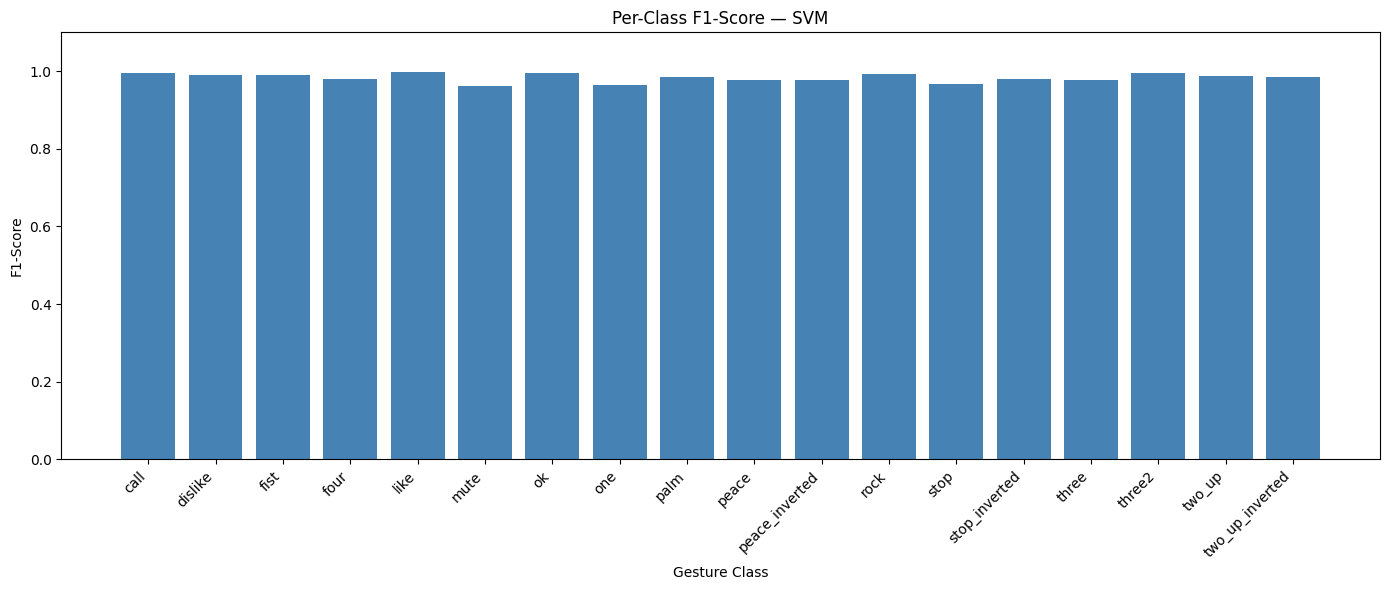

In [36]:
plot_perclass_f1(model_name, SVCPreds, Y_test, le.classes_)

**SVM** performed the best out of the 4 Models.
- Now we can only push it further using a **soft voting classifier**

## **Voting Ensemble Model**

## Now, lets try combining all the successfull model into an ensemble model using **VotingClassifier** library from **sklearn**
#### We will be using soft voting to aggregate all probabilities for each class and then predict based on them using the 4 previous models

In [37]:
from sklearn.ensemble import VotingClassifier
model_name="VotingClassifier"

In [38]:
VotingModel = VotingClassifier(
    estimators=[
        ('rf', RF_Model),
        ('xgb', XGB_Model),
        ('knn', KNN_Model),
        ('svm', SVM_Model)
    ],
    voting='soft' # here is where we specify that we want to use soft voting
)
VotingModel.fit(X_train, Y_train)

,estimators,"[('rf', ...), ('xgb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_estimators,200
,criterion,'gini'
,max_depth,1000
,min_samples_split,2
,min_samples_leaf,1


In [39]:
VotingModelPreds = VotingModel.predict(X_test) # accumulate predictions from all models and make final prediction based on majority vote of probabilities

## **Evaluation for the Ensemble Approach**

In [40]:
VotingModelAccuracy = accuracy_score(Y_test, VotingModelPreds)
print(f"Voting Classifier Test Accuracy: {VotingModelAccuracy:.4f} ({VotingModelAccuracy*100:.2f}%)")

votingModelTrainAccuracy = accuracy_score(Y_train, VotingModel.predict(X_train))
print(f"Voting Classifier Training Accuracy: {votingModelTrainAccuracy:.4f} ({votingModelTrainAccuracy*100:.2f}%)")

print()
precision = precision_score(Y_test, VotingModelPreds, average='macro', zero_division=0)
recall = recall_score(Y_test, VotingModelPreds, average='macro', zero_division=0)
f1 = f1_score(Y_test, VotingModelPreds, average='macro', zero_division=0)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Voting Classifier Test Accuracy: 0.9842 (98.42%)
Voting Classifier Training Accuracy: 1.0000 (100.00%)

Precision: 0.9837
Recall: 0.9838
F1-Score: 0.9837


## **Voting Classifier Confusion Matrix**

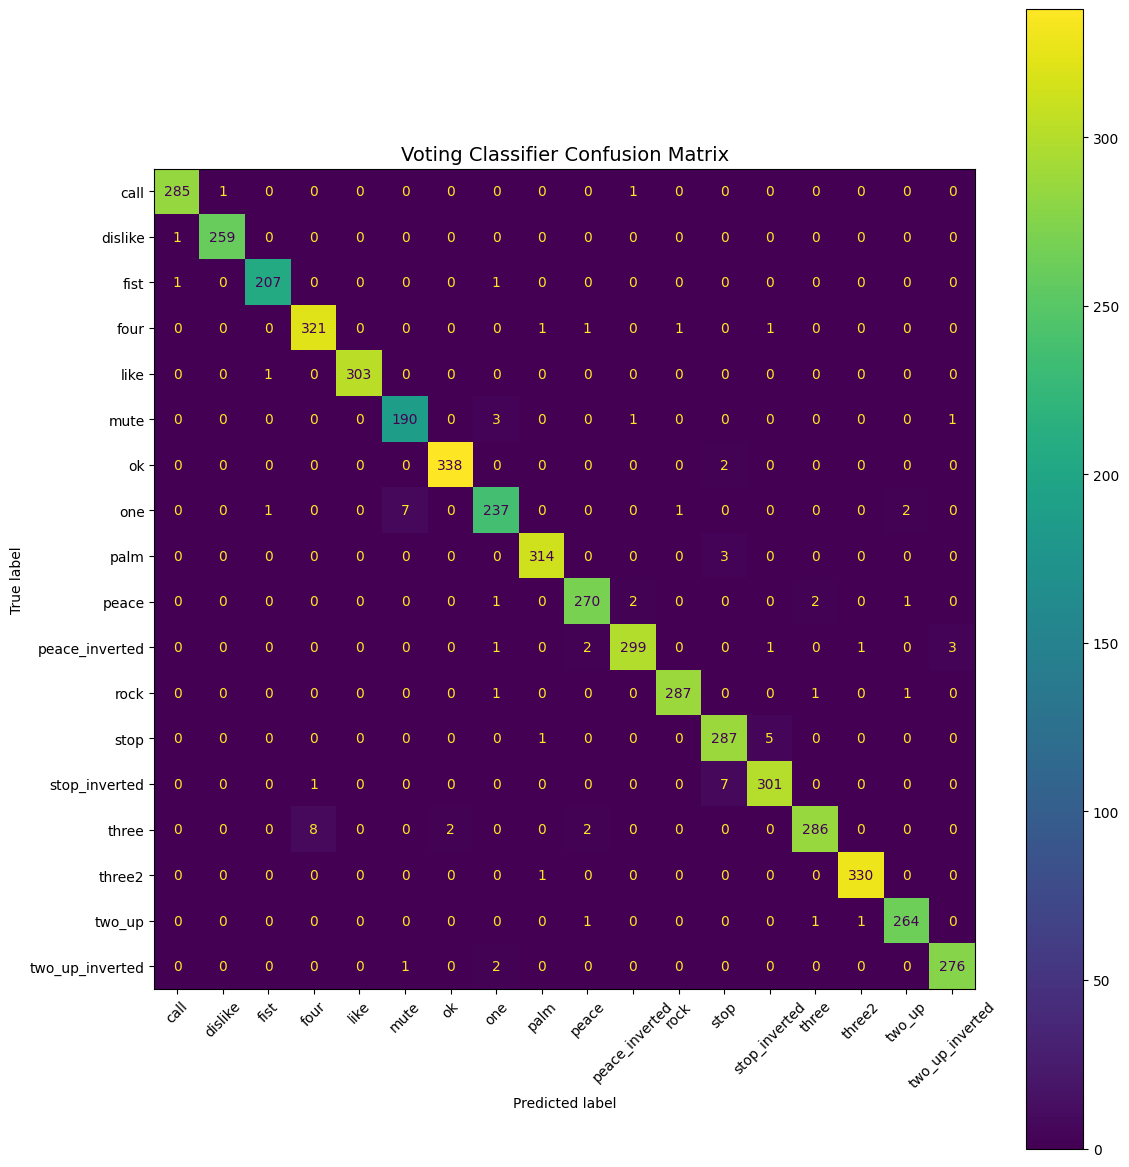

In [41]:
cm = confusion_matrix(Y_test, VotingModelPreds)
fig, ax = plt.subplots(figsize=(12, 12))
CmPath = 'assets/VotingClassifier/VC_CM.png'
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='viridis', xticks_rotation=45, ax=ax, colorbar=True)
ax.set_title("Voting Classifier Confusion Matrix", fontsize=14)
plt.savefig(CmPath)
plt.tight_layout()
plt.show()

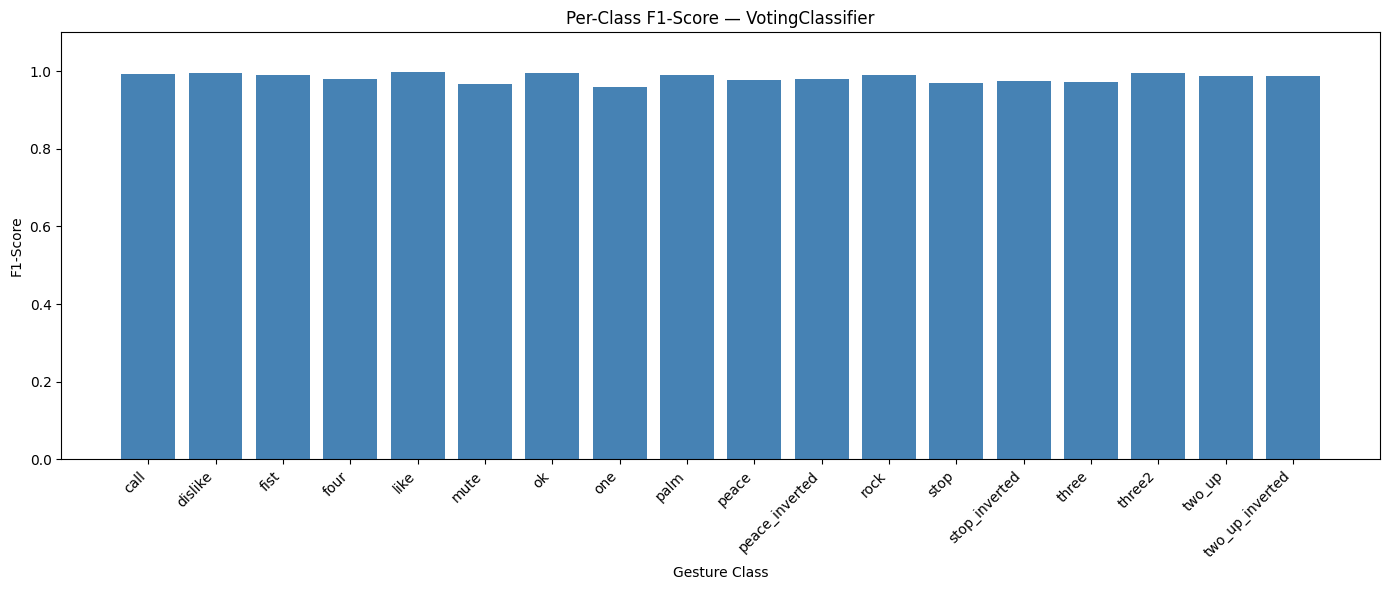

In [42]:
plot_perclass_f1(model_name, VotingModelPreds, Y_test, le.classes_)

## **Plotting Final Comparison**

##### Storing all Predictions for different models

In [43]:

RfPreds = RF_Model.predict(X_test)
KNNPreds = KNN_Model.predict(X_test)
XgboostPreds = XGB_Model.predict(X_test)
SVCPreds = SVM_Model.predict(X_test)
finalPreds = VotingModel.predict(X_test)

##### Evaluating all Test Accuracies and F1 Scores

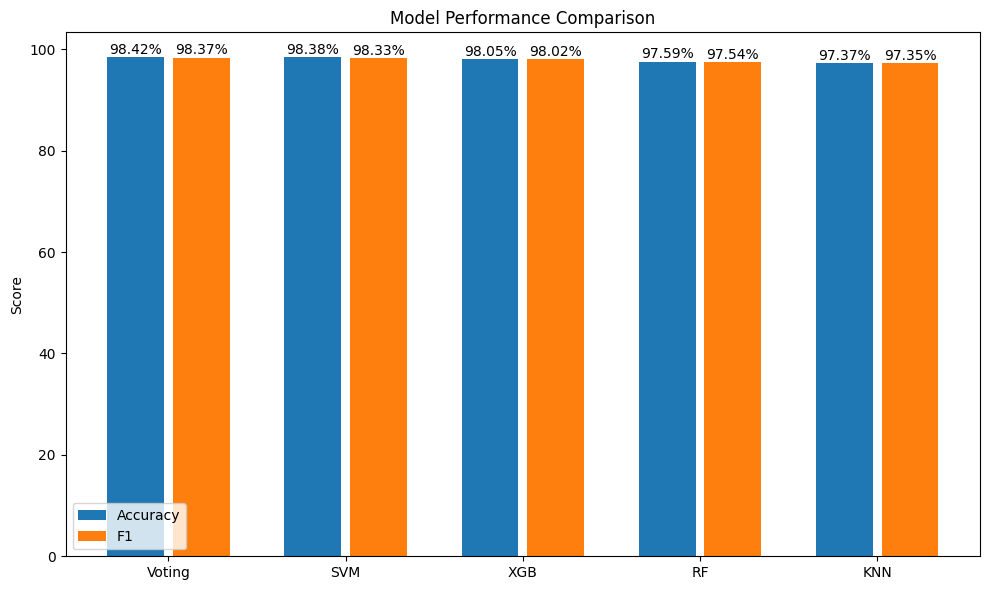

In [44]:
models = ["RF","KNN","XGB","SVM","Voting"]

accuracies = [
    accuracy_score(Y_test, RfPreds),
    accuracy_score(Y_test, KNNPreds),
    accuracy_score(Y_test, XgboostPreds),
    accuracy_score(Y_test, SVCPreds),
    accuracy_score(Y_test, finalPreds)
]
accuracies = [x*100 for x in accuracies]
f1s = [
    f1_score(Y_test, RfPreds, average='macro', zero_division=0),
    f1_score(Y_test, KNNPreds, average='macro', zero_division=0),
    f1_score(Y_test, XgboostPreds, average='macro', zero_division=0),
    f1_score(Y_test, SVCPreds, average='macro', zero_division=0),
    f1_score(Y_test, finalPreds, average='macro', zero_division=0)
]
f1s = [f*100 for f in f1s]

# sort by accuracy descending
order = np.argsort(accuracies)[::-1]

models = [models[i] for i in order]
accuracies = [accuracies[i] for i in order]
f1s = [f1s[i] for i in order]

x = np.arange(len(models))
width = 0.32   # slightly smaller for more gap

fig, ax = plt.subplots(figsize=(10,6))
gap = 0.05

bars1 = ax.bar(x - width/2 - gap/2, accuracies, width, label="Accuracy")
bars2 = ax.bar(x + width/2 + gap/2, f1s, width, label="F1")

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")

# add headroom so labels fit
# ax.set_ylim(0, max(max(accuracies), max(f1s)) + 0.05)

# annotate bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.2f}%",
            ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.2f}%",
            ha='center', va='bottom', fontsize=10)

ax.legend()
plt.tight_layout()
plt.show()

##### Here we are Comparing the best checkpoint for each of the following models

### **MediaPipe** Piepline alongside **OpenCV**
- to show the landmarks on the hand and detect the prediction in a realtime video + Saving it for reference

In [45]:
mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    max_num_hands=1,
    min_detection_confidence=0.8,
    min_tracking_confidence=0.8
)

cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1920)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 1080)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = 10
fourcc = cv2.VideoWriter_fourcc(*'X264')
out = cv2.VideoWriter('HaGRID_output.mp4', fourcc, fps, (width, height))

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)
    h, w, _ = frame.shape
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result = hands.process(img_rgb)

    gesture_rf = ""
    gesture_xgboost = ""
    gesture_knn = ""
    gesture_svm = ""
    gesture_VM = ""

    if result.multi_hand_landmarks:
        for hand_landmarks in result.multi_hand_landmarks:
            mp_draw.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)
            landmark_dict = {}
            for i, lm in enumerate(hand_landmarks.landmark):
                landmark_dict[f'x{i+1}'] = 1.0 - lm.x
                landmark_dict[f'y{i+1}'] = lm.y
                landmark_dict[f'z{i+1}'] = lm.z

            realtime_df = pd.DataFrame([landmark_dict])
            realtime_df = realtime_df[X_train.columns]
            normalized_realtime_df = normalize_landmarks(realtime_df)
            # predict with all models
            pred_rf = RF_Model.predict(normalized_realtime_df)
            pred_Knn = KNN_Model.predict(normalized_realtime_df)
            pred_Xgboost = XGB_Model.predict(normalized_realtime_df)
            pred_svm = SVM_Model.predict(normalized_realtime_df)
            pred_VM = VotingModel.predict(normalized_realtime_df)
            # inverse transform to get gesture labels
            gesture_rf = le.inverse_transform(pred_rf)[0]
            gesture_knn = le.inverse_transform(pred_Knn)[0]
            gesture_xgboost = le.inverse_transform(pred_Xgboost)[0]
            gesture_svm = le.inverse_transform(pred_svm)[0]
            gesture_VM = le.inverse_transform(pred_VM)[0]

    cv2.putText(frame, f'RF: {gesture_rf}', (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2)
    cv2.putText(frame, f'XGBoost: {gesture_xgboost}', (10, 100), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 0, 0), 2)
    cv2.putText(frame, f'KNN: {gesture_knn}', (10, 150), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2)
    cv2.putText(frame, f'SVM: {gesture_svm}', (10, 200), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 0), 2)
    
    text = f'Final Voting Classifier: {gesture_VM}'
    text_size = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 1, 3)[0]
    cv2.rectangle(frame, ((frame.shape[1]-text_size[0])//2-10, 50-text_size[1]-10), ((frame.shape[1]-text_size[0])//2+text_size[0]+10, 50+10), (255, 255, 255), 2)
    cv2.putText(frame, text, ((frame.shape[1]-text_size[0])//2, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 3)
    cv2.imshow("HaGRID Real-Time - 5 Models Comparison", frame)

    out.write(frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
out.release()
cv2.destroyAllWindows()
hands.close()

I0000 00:00:1773357007.799397 55736622 gl_context.cc:369] GL version: 2.1 (2.1 ATI-5.2.5), renderer: AMD Radeon Pro 5500M OpenGL Engine
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1773357007.884855 55795664 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773357007.952144 55795664 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
OpenCV: FFMPEG: tag 0x34363258/'X264' is not supported with codec id 27 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x31637661/'avc1'
W0000 00:00:1773357010.218962 55795667 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


### **Conclusion**

Based on the evaluation metrics, all individual models demonstrated strong performance, with all having test accuracies above **97%**, indicating that the dataset is well-structured and learnable by multiple algorithms.

Among the standalone models, **XGBoost** and **SVM** achieved the highest test accuracies (**98.05%** and **98.38%** respectively), with balanced precision, recall, and F1-scores, suggesting consistent classification performance.  
**Random Forest** also performed very well but showed a larger gap between training accuracy (**100%**) and test accuracy (**97.6%**), indicating slight overfitting.  
**KNN** had the lowest performance among the models, but still maintained strong generalization with stable metrics across all evaluation scores.

The **Voting Classifier** outperformed all individual models, achieving the highest test accuracy of **98.42%** along with balanced precision, recall, and F1-score (~**98.4%**). This demonstrates the strength of ensemble learning, where combining diverse models improves robustness and reduces individual model weaknesses.

Additionally, the Voting Classifier achieved the best overall test-set performance while maintaining highly consistent precision, recall, and F1-score across classes.

- here is a wrap up table for the metrics and performances of the models:

| Model              | Test Accuracy (%) | F1 Score (%) |
|--------------------|------------------|--------------|
| Random Forest      | 97.59            | 97.54        |
| KNN                | 97.37            | 97.35        |
| XGBoost            | 98.05            | 98.02        |
| SVM                | 98.38            | 98.33        |
| Voting Classifier  | 98.42            | 98.37        |

##### Overall, the ensemble approach (Voting Model) proved to be the most reliable solution, delivering the best trade-off between accuracy, stability, and generalization, making it the preferred model for deployment, since it brings all the models to the table in one go.


##### Video Showing Results using MediaPipe & OpenCV: [Link](https://drive.google.com/file/d/1CEhAqZW-axCK3SgaYa5Gfzsr7EMKBYQQ/view)

# **Thank You**